# Commodity Price Prediction — DeBERTa Multi-Task LSTM Pipeline

This notebook restructures the LSTM workflow to follow the same section flow as `full_pipeline_v3`, but uses the **precomputed DeBERTa daily sentiment features** from `finetuning/outputs/daily_topic_sentiment.csv`.

Pipeline flow:
1. Setup and configuration  
2. Load price data  
3. Load DeBERTa daily sentiment features  
4. Merge and engineer features  
5. Chronological train/val/test split  
6. Multi-task LSTM model  
7. Training loop  
8. Evaluation  
9. Visualisation  
10. Optional sweep for `TIME_STEPS` and `LOSS_ALPHA`


In [ ]:
# ── 0. Colab Setup (skip if running locally) ────────────────────────────────
# Uncomment if you are running in Colab and want to mount Drive.
# from google.colab import drive
# drive.mount('/content/drive')


In [1]:
# ── 1. Imports & Configuration ───────────────────────────────────────────────
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

warnings.filterwarnings("ignore")

try:
    _in_colab = "google.colab" in str(get_ipython())  # type: ignore
except NameError:
    _in_colab = False

if _in_colab:
    BASE = Path("/content/drive/MyDrive/Project")  # change if needed
else:
    BASE = Path.cwd().parent  # notebook is in finetuning/

RAW_DATA_DIR = BASE / "data" / "raw"
PRICE_FILE_MAP = {
    "brent": RAW_DATA_DIR / "daily_last_2y" / "csv" / "brent_daily_20260228_075143.csv",
    # update these if your filenames differ
    "wti": RAW_DATA_DIR / "daily_last_2y" / "csv" / "wti_daily_20260228_075143.csv",
    "natural_gas": RAW_DATA_DIR / "daily_last_2y" / "csv" / "natural_gas_daily_20260228_075143.csv",
    "silver": RAW_DATA_DIR / "daily_last_2y" / "csv" / "silver_daily_20260228_075143.csv",
}

DEBERTA_DAILY_FILE = BASE / "finetuning" / "outputs" / "daily_topic_sentiment.csv"
OUT_DIR = BASE / "finetuning" / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_COMMODITY = "brent"    # brent | wti | natural_gas | silver
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

TIME_STEPS = 10
BATCH_SIZE = 32
LR = 1e-3
EPOCHS = 50
HIDDEN_SIZE = 64
NUM_LAYERS = 2
DROPOUT = 0.3
LOSS_ALPHA = 0.5   # α in α*MSE + (1-α)*BCE
RANDOM_SEED = 42

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

EVENT_CATEGORIES = [
    "supply", "demand", "inventory", "transport",
    "policy", "weather", "macro", "outage"
]

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

print("BASE:", BASE)
print("TARGET_COMMODITY:", TARGET_COMMODITY)
print("PRICE_FILE:", PRICE_FILE_MAP[TARGET_COMMODITY])
print("PRICE_FILE exists:", PRICE_FILE_MAP[TARGET_COMMODITY].exists())
print("DEBERTA_DAILY_FILE:", DEBERTA_DAILY_FILE)
print("DEBERTA_DAILY_FILE exists:", DEBERTA_DAILY_FILE.exists())
print("DEVICE:", DEVICE)


BASE: c:\Users\diant\OneDrive\Documents\Term 8\CDS\DS_Project_g8
TARGET_COMMODITY: brent
PRICE_FILE: c:\Users\diant\OneDrive\Documents\Term 8\CDS\DS_Project_g8\data\raw\daily_last_2y\csv\brent_daily_20260228_075143.csv
PRICE_FILE exists: True
DEBERTA_DAILY_FILE: c:\Users\diant\OneDrive\Documents\Term 8\CDS\DS_Project_g8\finetuning\outputs\daily_topic_sentiment.csv
DEBERTA_DAILY_FILE exists: True
DEVICE: cuda


In [2]:
# ── 2. Load Price Data ───────────────────────────────────────────────────────
def load_price_file(price_file: Path) -> pd.DataFrame:
    if not price_file.exists():
        raise FileNotFoundError(f"Price file not found: {price_file}")

    if price_file.suffix.lower() == ".csv":
        df = pd.read_csv(price_file)
    else:
        with open(price_file, "r", encoding="utf-8") as f:
            raw = json.load(f)
        if isinstance(raw, dict) and "data" in raw:
            df = pd.DataFrame(raw["data"])
        else:
            df = pd.DataFrame(raw)

    if "value" in df.columns and "price" not in df.columns:
        df = df.rename(columns={"value": "price"})
    if "close" in df.columns and "price" not in df.columns:
        df = df.rename(columns={"close": "price"})

    if "date" not in df.columns:
        raise ValueError(f"'date' column not found in price file: {price_file}")
    if "price" not in df.columns:
        raise ValueError(f"'price' column not found in price file: {price_file}")

    df["date"] = pd.to_datetime(df["date"])
    df["price"] = pd.to_numeric(df["price"], errors="coerce")
    df = df.sort_values("date").reset_index(drop=True)

    print(f"{len(df)} rows | {df['date'].min().date()} → {df['date'].max().date()}")
    return df

price_df = load_price_file(PRICE_FILE_MAP[TARGET_COMMODITY])
display(price_df.head())


517 rows | 2024-03-01 → 2026-02-23


,date,price
0,2024-03-01,84.82
1,2024-03-04,86.58
2,2024-03-05,85.82
3,2024-03-06,86.59
4,2024-03-07,84.88


In [3]:
# ── 3. Load DeBERTa Daily Sentiment Features ────────────────────────────────
def load_deberta_daily_features(path: Path, commodity: str | None = None) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"DeBERTa daily file not found: {path}")

    df = pd.read_csv(path)

    print("Raw DeBERTa columns:", df.columns.tolist())

    # date column
    if "trading_day" in df.columns:
        df["trading_day"] = pd.to_datetime(df["trading_day"])
    elif "date" in df.columns:
        df = df.rename(columns={"date": "trading_day"})
        df["trading_day"] = pd.to_datetime(df["trading_day"])
    elif "published_at" in df.columns:
        df = df.rename(columns={"published_at": "trading_day"})
        df["trading_day"] = pd.to_datetime(df["trading_day"])
    else:
        raise ValueError(f"Expected trading_day/date column. Found: {df.columns.tolist()}")

    # optional filter if commodity column exists
    if commodity is not None and "commodity" in df.columns:
        df = df[df["commodity"].fillna("").str.lower() == commodity.lower()].copy()

    expected_base = [
        "avg_sentiment",
        "sentiment_std",
        "news_volume",
        "log_news_vol",
        "composite_price_signal",
    ]

    for col in expected_base:
        if col not in df.columns:
            if col == "log_news_vol" and "news_volume" in df.columns:
                df["log_news_vol"] = np.log1p(df["news_volume"])
            else:
                df[col] = 0.0

    for cat in EVENT_CATEGORIES:
        for suffix in ["price_signal", "count"]:
            col = f"{cat}_{suffix}"
            if col not in df.columns:
                df[col] = 0.0

    keep_cols = (
        ["trading_day", "avg_sentiment", "sentiment_std", "news_volume",
         "log_news_vol", "composite_price_signal"]
        + [f"{cat}_price_signal" for cat in EVENT_CATEGORIES]
        + [f"{cat}_count" for cat in EVENT_CATEGORIES]
    )

    optional_cols = ["topic_w_sentiment", "sentiment_volw"]
    for c in optional_cols:
        if c in df.columns:
            keep_cols.append(c)

    out = df[keep_cols].copy()

    if "topic_w_sentiment" not in out.columns:
        out["topic_w_sentiment"] = 0.0
    if "sentiment_volw" not in out.columns:
        out["sentiment_volw"] = out["avg_sentiment"] * out["log_news_vol"]

    # important: ensure one row per trading day
    dupes = out["trading_day"].duplicated().sum()
    if dupes > 0:
        print(f"Found {dupes} duplicated trading_day rows. Aggregating by day...")
        numeric_cols = [c for c in out.columns if c != "trading_day"]
        out = out.groupby("trading_day", as_index=False)[numeric_cols].sum()

    out = out.sort_values("trading_day").reset_index(drop=True)

    print("DeBERTa daily features shape:", out.shape)
    display(out.head())
    return out

daily_df = load_deberta_daily_features(DEBERTA_DAILY_FILE, commodity=TARGET_COMMODITY)
print("Unique trading days:", daily_df["trading_day"].nunique())
print("Duplicate trading days:", daily_df["trading_day"].duplicated().sum())


Raw DeBERTa columns: ['date', 'topic', 'news_volume', 'avg_sentiment', 'median_sentiment', 'sentiment_std', 'max_sentiment', 'min_sentiment', 'avg_prob_positive', 'avg_prob_negative', 'avg_prob_neutral', 'sentiment_volume_weighted']
Found 636 duplicated trading_day rows. Aggregating by day...
DeBERTa daily features shape: (630, 24)


,trading_day,avg_sentiment,sentiment_std,news_volume,log_news_vol,composite_price_signal,supply_price_signal,demand_price_signal,inventory_price_signal,transport_price_signal,...,supply_count,demand_count,inventory_count,transport_count,policy_count,weather_count,macro_count,outage_count,topic_w_sentiment,sentiment_volw
0,2024-04-01,0.988299,0.000000,1,0.693147,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.685037
1,2024-04-02,1.962301,0.000000,2,1.386294,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.360163
2,2024-04-03,0.477802,1.920787,4,2.197225,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.524919
3,2024-04-04,1.319895,1.149543,4,2.079442,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.143387
4,2024-04-05,-0.527238,1.114527,5,2.484907,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.474949


Unique trading days: 630
Duplicate trading days: 0


In [4]:
# ── 4. Merge & Feature Engineering ───────────────────────────────────────────
def build_panel(price_df: pd.DataFrame, daily_df: pd.DataFrame) -> pd.DataFrame:
    df = price_df.copy()
    df = df.rename(columns={"date": "trading_day", "price": "Close"})

    # Price-derived features
    df["log_return"] = np.log(df["Close"]).diff()
    df["return_1"] = df["Close"].pct_change(1)
    df["return_lag1"] = df["return_1"].shift(1)
    df["rolling_vol_7"] = df["return_1"].rolling(7).std()
    df["roll5_ret"] = df["return_1"].rolling(5).mean()
    df["roll20_vol"] = df["return_1"].rolling(20).std()
    df["ma5_ratio"] = df["Close"] / df["Close"].rolling(5).mean()
    df["ma20_ratio"] = df["Close"] / df["Close"].rolling(20).mean()

    # Merge DeBERTa daily sentiment features
    df = df.merge(daily_df, on="trading_day", how="left")

    sentiment_cols = (
        ["avg_sentiment", "sentiment_std", "news_volume", "log_news_vol",
         "composite_price_signal", "topic_w_sentiment", "sentiment_volw"]
        + [f"{cat}_price_signal" for cat in EVENT_CATEGORIES]
        + [f"{cat}_count" for cat in EVENT_CATEGORIES]
    )

    for c in sentiment_cols:
        if c not in df.columns:
            df[c] = 0.0
        df[c] = df[c].fillna(0)

    # lag all sentiment features by one day to avoid leakage
    df[sentiment_cols] = df[sentiment_cols].shift(1)

    # targets
    df["target_close_next"] = df["Close"].shift(-1)
    df["target_return_next"] = np.log(df["target_close_next"] / df["Close"])
    df["target_up"] = (df["target_return_next"] > 0).astype(int)

    df = df.dropna().reset_index(drop=True)
    return df

panel = build_panel(price_df, daily_df)
print("Panel shape:", panel.shape)
display(panel.head())

FEATURE_COLS = [
    "Close",
    "avg_sentiment",
    "sentiment_std",
    "news_volume",
    "log_news_vol",
    "topic_w_sentiment",
    "sentiment_volw",
    "composite_price_signal",
    "return_lag1",
    "rolling_vol_7",
    "roll5_ret",
    "roll20_vol",
    "ma5_ratio",
    "ma20_ratio",
] + [f"{cat}_price_signal" for cat in EVENT_CATEGORIES] + [f"{cat}_count" for cat in EVENT_CATEGORIES]

print("n_features =", len(FEATURE_COLS))
missing = [c for c in FEATURE_COLS if c not in panel.columns]
print("Missing feature columns:", missing)


Panel shape: (291, 36)


,trading_day,Close,log_return,return_1,return_lag1,rolling_vol_7,roll5_ret,roll20_vol,ma5_ratio,ma20_ratio,...,transport_count,policy_count,weather_count,macro_count,outage_count,topic_w_sentiment,sentiment_volw,target_close_next,target_return_next,target_up
0,2024-04-30,88.23,-0.002377,-0.002374,-0.016787,0.013457,-0.000046,0.015731,0.994163,0.979751,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.215196,83.55,-0.054502,0
1,2024-05-01,83.55,-0.054502,-0.053043,-0.002374,0.024476,-0.012308,0.017871,0.953180,0.931428,...,0.0,0.0,0.0,0.0,0.0,0.0,0.594180,84.81,0.014968,1
2,2024-05-02,84.81,0.014968,0.015081,-0.053043,0.024954,-0.007225,0.018369,0.974872,0.948387,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.689485,83.60,-0.014370,0
3,2024-06-25,86.81,0.000691,0.000692,0.003819,0.009338,0.004725,0.015479,1.005816,1.066967,...,0.0,0.0,0.0,0.0,0.0,0.0,0.257485,85.76,-0.012169,0
4,2024-06-26,85.76,-0.012169,-0.012095,0.000692,0.012140,0.000301,0.015861,0.993374,1.051309,...,0.0,0.0,0.0,0.0,0.0,0.0,-1.544100,87.00,0.014355,1


n_features = 30
Missing feature columns: []


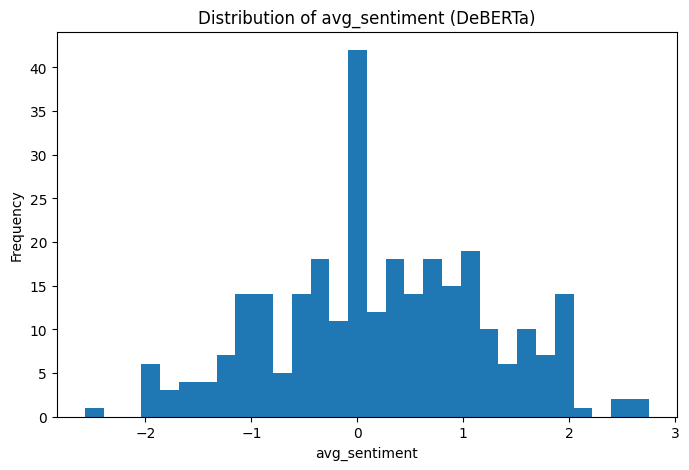

In [13]:
# ── Sentiment Distribution ─────────────────────────────────────────────
plt.figure(figsize=(8,5))
plt.hist(panel['avg_sentiment'].dropna(), bins=30)
plt.title('Distribution of avg_sentiment (DeBERTa)')
plt.xlabel('avg_sentiment')
plt.ylabel('Frequency')
plt.show()

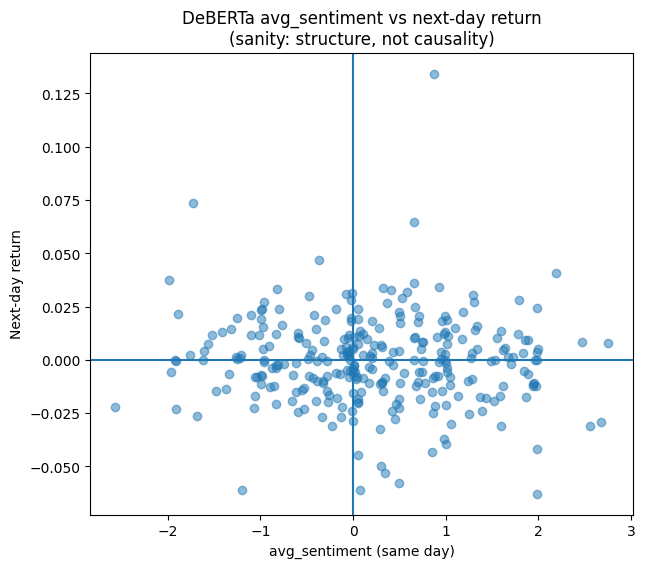

In [17]:
# ── Sentiment vs Next-Day Return ───────────────────────────────────────
panel['next_return'] = panel['Close'].pct_change().shift(-1)

plt.figure(figsize=(7,6))
plt.scatter(panel['avg_sentiment'], panel['next_return'], alpha=0.5)

plt.axhline(0)
plt.axvline(0)

plt.title('DeBERTa avg_sentiment vs next-day return\n(sanity: structure, not causality)')
plt.xlabel('avg_sentiment (same day)')
plt.ylabel('Next-day return')

plt.show()

In [5]:
# ── 5. Train / Val / Test Split + Scaling + Dataset ──────────────────────────
class MultiTaskSequenceDataset(Dataset):
    def __init__(self, X, y_reg, y_cls):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y_reg = torch.tensor(y_reg, dtype=torch.float32)
        self.y_cls = torch.tensor(y_cls, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y_reg[idx], self.y_cls[idx]


def make_splits(panel_df: pd.DataFrame, feature_cols: list[str], time_steps: int):
    n = len(panel_df)
    i_train_end = int(n * TRAIN_RATIO)
    i_val_end = int(n * (TRAIN_RATIO + VAL_RATIO))

    train_df = panel_df.iloc[:i_train_end].copy()
    val_df = panel_df.iloc[i_train_end:i_val_end].copy()
    test_df = panel_df.iloc[i_val_end:].copy()

    scaler = MinMaxScaler()
    scaler.fit(train_df[feature_cols])

    full_scaled = scaler.transform(panel_df[feature_cols])
    target_close_raw = panel_df["Close"].values.astype(float)
    close_idx = feature_cols.index("Close")

    def build_windows(i_lo, i_hi_excl):
        X, y_reg, y_cls, meta_idx = [], [], [], []
        for i in range(i_lo, i_hi_excl):
            t = i + time_steps
            if t < 1 or t >= n:
                continue
            X.append(full_scaled[i:i+time_steps])
            y_reg.append(full_scaled[t, close_idx])

            c0 = float(target_close_raw[t-1])
            c1 = float(target_close_raw[t])
            lr = np.log(max(c1, 1e-12) / max(c0, 1e-12))
            y_cls.append(1.0 if lr > 0 else 0.0)
            meta_idx.append(t)
        return (
            np.array(X, dtype=np.float32),
            np.array(y_reg, dtype=np.float32).reshape(-1, 1),
            np.array(y_cls, dtype=np.float32).reshape(-1, 1),
            np.array(meta_idx, dtype=int)
        )

    train_pack = build_windows(0, max(0, i_train_end - time_steps))
    val_pack = build_windows(i_train_end - time_steps, max(0, i_val_end - time_steps))
    test_pack = build_windows(i_val_end - time_steps, max(0, n - time_steps))

    return {
        "train": train_pack,
        "val": val_pack,
        "test": test_pack,
        "scaler": scaler,
        "close_idx": close_idx,
        "target_close_raw": target_close_raw,
        "i_train_end": i_train_end,
        "i_val_end": i_val_end,
    }

split = make_splits(panel, FEATURE_COLS, TIME_STEPS)
(X_train, y_reg_train, y_cls_train, idx_train) = split["train"]
(X_val, y_reg_val, y_cls_val, idx_val) = split["val"]
(X_test, y_reg_test, y_cls_test, idx_test) = split["test"]

print("Train sequences:", len(X_train))
print("Val sequences:", len(X_val))
print("Test sequences:", len(X_test))


Train sequences: 193
Val sequences: 44
Test sequences: 44


In [6]:
# ── 6. Multi-Task LSTM Model ─────────────────────────────────────────────────
class MultiTaskLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.3):
        super().__init__()
        lstm_dropout = dropout if num_layers > 1 else 0.0
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=lstm_dropout,
        )
        self.price_head = nn.Linear(hidden_size, 1)
        self.dir_head = nn.Sequential(
            nn.Linear(hidden_size, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        h_t = out[:, -1, :]
        pred_price = self.price_head(h_t)
        pred_logit = self.dir_head(h_t)
        return pred_price, pred_logit


def make_loaders(split_dict, batch_size=32):
    train_ds = MultiTaskSequenceDataset(*split_dict["train"][:3])
    val_ds = MultiTaskSequenceDataset(*split_dict["val"][:3])
    test_ds = MultiTaskSequenceDataset(*split_dict["test"][:3])

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=False)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = make_loaders(split, BATCH_SIZE)

model = MultiTaskLSTM(
    input_size=len(FEATURE_COLS),
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
).to(DEVICE)

pos = float(y_cls_train.sum())
neg = float(len(y_cls_train) - pos)
pos_weight_value = neg / max(pos, 1.0)
pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32, device=DEVICE)

mse_loss = nn.MSELoss()
bce_loss = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)

print(model)
print("pos_weight:", pos_weight_value)


MultiTaskLSTM(
  (lstm): LSTM(30, 64, num_layers=2, batch_first=True, dropout=0.3)
  (price_head): Linear(in_features=64, out_features=1, bias=True)
  (dir_head): Sequential(
    (0): Linear(in_features=64, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=1, bias=True)
  )
)
pos_weight: 1.120879120879121


In [7]:
# ── 7. Training Loop ─────────────────────────────────────────────────────────
def run_epoch(model, loader, optimizer=None, alpha=0.5):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, total_mse, total_bce, n_batches = 0.0, 0.0, 0.0, 0

    with torch.set_grad_enabled(is_train):
        for Xb, y_reg_b, y_cls_b in loader:
            Xb = Xb.to(DEVICE)
            y_reg_b = y_reg_b.to(DEVICE)
            y_cls_b = y_cls_b.to(DEVICE)

            pred_reg, pred_logit = model(Xb)
            loss_mse = mse_loss(pred_reg, y_reg_b)
            loss_bce = bce_loss(pred_logit, y_cls_b)
            loss = alpha * loss_mse + (1 - alpha) * loss_bce

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += float(loss.item())
            total_mse += float(loss_mse.item())
            total_bce += float(loss_bce.item())
            n_batches += 1

    return {
        "loss": total_loss / max(n_batches, 1),
        "mse": total_mse / max(n_batches, 1),
        "bce": total_bce / max(n_batches, 1),
    }


history = {"train_loss": [], "val_loss": [], "train_mse": [], "val_mse": [], "train_bce": [], "val_bce": []}

best_val = float("inf")
best_state = None
patience = 15
wait = 0

for epoch in range(1, EPOCHS + 1):
    train_stats = run_epoch(model, train_loader, optimizer=optimizer, alpha=LOSS_ALPHA)
    val_stats = run_epoch(model, val_loader, optimizer=None, alpha=LOSS_ALPHA)

    history["train_loss"].append(train_stats["loss"])
    history["val_loss"].append(val_stats["loss"])
    history["train_mse"].append(train_stats["mse"])
    history["val_mse"].append(val_stats["mse"])
    history["train_bce"].append(train_stats["bce"])
    history["val_bce"].append(val_stats["bce"])

    if val_stats["loss"] < best_val:
        best_val = val_stats["loss"]
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        wait = 0
    else:
        wait += 1

    if epoch == 1 or epoch % 5 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"train_loss={train_stats['loss']:.4f} val_loss={val_stats['loss']:.4f} | "
            f"train_mse={train_stats['mse']:.4f} val_mse={val_stats['mse']:.4f} | "
            f"train_bce={train_stats['bce']:.4f} val_bce={val_stats['bce']:.4f}"
        )

    if wait >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

if best_state is not None:
    model.load_state_dict(best_state)
    print("Loaded best validation checkpoint.")


Epoch 001 | train_loss=0.4383 val_loss=0.3998 | train_mse=0.1508 val_mse=0.0611 | train_bce=0.7258 val_bce=0.7386
Epoch 005 | train_loss=0.3845 val_loss=0.4260 | train_mse=0.0476 val_mse=0.1082 | train_bce=0.7214 val_bce=0.7439
Epoch 010 | train_loss=0.3765 val_loss=0.4221 | train_mse=0.0339 val_mse=0.0948 | train_bce=0.7192 val_bce=0.7493
Epoch 015 | train_loss=0.3699 val_loss=0.3976 | train_mse=0.0206 val_mse=0.0461 | train_bce=0.7192 val_bce=0.7491
Epoch 020 | train_loss=0.3670 val_loss=0.3929 | train_mse=0.0146 val_mse=0.0362 | train_bce=0.7195 val_bce=0.7497
Epoch 025 | train_loss=0.3661 val_loss=0.3881 | train_mse=0.0129 val_mse=0.0263 | train_bce=0.7194 val_bce=0.7498
Epoch 030 | train_loss=0.3654 val_loss=0.3873 | train_mse=0.0114 val_mse=0.0240 | train_bce=0.7194 val_bce=0.7507
Epoch 035 | train_loss=0.3640 val_loss=0.3843 | train_mse=0.0092 val_mse=0.0164 | train_bce=0.7188 val_bce=0.7523
Epoch 040 | train_loss=0.3643 val_loss=0.3858 | train_mse=0.0106 val_mse=0.0164 | train_

In [8]:
# ── 8. Evaluation ────────────────────────────────────────────────────────────
def invert_close_from_scaled(scaled_close, scaler, close_idx):
    arr = np.zeros((len(scaled_close), len(FEATURE_COLS)))
    arr[:, close_idx] = scaled_close.reshape(-1)
    inv = scaler.inverse_transform(arr)
    return inv[:, close_idx]

def evaluate_model(model, loader, split_dict, idx_meta, alpha=0.5):
    model.eval()

    pred_reg_all, pred_logit_all = [], []
    y_reg_all, y_cls_all = [], []

    with torch.no_grad():
        for Xb, y_reg_b, y_cls_b in loader:
            Xb = Xb.to(DEVICE)
            pred_reg, pred_logit = model(Xb)

            pred_reg_all.append(pred_reg.detach().cpu().numpy())
            pred_logit_all.append(pred_logit.detach().cpu().numpy())
            y_reg_all.append(y_reg_b.numpy())
            y_cls_all.append(y_cls_b.numpy())

    pred_reg_scaled = np.vstack(pred_reg_all).reshape(-1)
    pred_logits = np.vstack(pred_logit_all).reshape(-1)
    y_reg_scaled = np.vstack(y_reg_all).reshape(-1)
    y_cls = np.vstack(y_cls_all).reshape(-1)

    scaler = split_dict["scaler"]
    close_idx = split_dict["close_idx"]
    raw_close = split_dict["target_close_raw"]

    pred_close = invert_close_from_scaled(pred_reg_scaled, scaler, close_idx)
    true_close = invert_close_from_scaled(y_reg_scaled, scaler, close_idx)

    rmse = np.sqrt(mean_squared_error(true_close, pred_close))
    mae = mean_absolute_error(true_close, pred_close)
    mape = np.mean(np.abs((true_close - pred_close) / np.maximum(np.abs(true_close), 1e-8))) * 100
    r2 = r2_score(true_close, pred_close)

    pred_prob = 1 / (1 + np.exp(-pred_logits))
    pred_cls = (pred_prob >= 0.5).astype(int)

    cls_acc = accuracy_score(y_cls, pred_cls)
    cls_f1 = f1_score(y_cls, pred_cls, zero_division=0)
    try:
        cls_auc = roc_auc_score(y_cls, pred_prob)
    except Exception:
        cls_auc = np.nan

    cm = confusion_matrix(y_cls, pred_cls, labels=[0, 1])

    # direction from predicted level vs previous close
    prev_close = raw_close[idx_meta - 1]
    actual_dir = (true_close > prev_close).astype(int)
    pred_dir = (pred_close > prev_close).astype(int)
    dir_acc = accuracy_score(actual_dir, pred_dir)

    mask_nz = true_close != prev_close
    if mask_nz.sum() > 0:
        dir_acc_nz = accuracy_score(actual_dir[mask_nz], pred_dir[mask_nz])
    else:
        dir_acc_nz = np.nan

    results = {
        "rmse": rmse,
        "mae": mae,
        "mape": mape,
        "r2": r2,
        "direction_accuracy": dir_acc,
        "direction_accuracy_nonzero_actual": dir_acc_nz,
        "cls_accuracy": cls_acc,
        "cls_f1": cls_f1,
        "cls_auc": cls_auc,
        "confusion_matrix": cm,
        "pred_close": pred_close,
        "true_close": true_close,
        "pred_prob": pred_prob,
        "pred_cls": pred_cls,
        "true_cls": y_cls,
        "idx_meta": idx_meta,
    }
    return results

res = evaluate_model(model, test_loader, split, idx_test, alpha=LOSS_ALPHA)

print("=== Test Metrics ===")
print(f"Regression: RMSE={res['rmse']:.4f} | MAE={res['mae']:.4f} | MAPE={res['mape']:.2f}% | R²={res['r2']:.4f}")
print(f"Direction from predicted level: acc={res['direction_accuracy']:.2%} | non-flat={res['direction_accuracy_nonzero_actual']:.2%}")
print(f"Classifier head: acc={res['cls_accuracy']:.2%} | F1={res['cls_f1']:.3f} | AUC={res['cls_auc']:.3f}")
print("Confusion matrix [actual down, up] × [pred down, up]:")
print(res["confusion_matrix"])


=== Test Metrics ===
Regression: RMSE=2.9990 | MAE=2.7417 | MAPE=4.19% | R²=0.4225
Direction from predicted level: acc=50.00% | non-flat=50.00%
Classifier head: acc=43.18% | F1=0.000 | AUC=0.579
Confusion matrix [actual down, up] × [pred down, up]:
[[19  0]
 [25  0]]


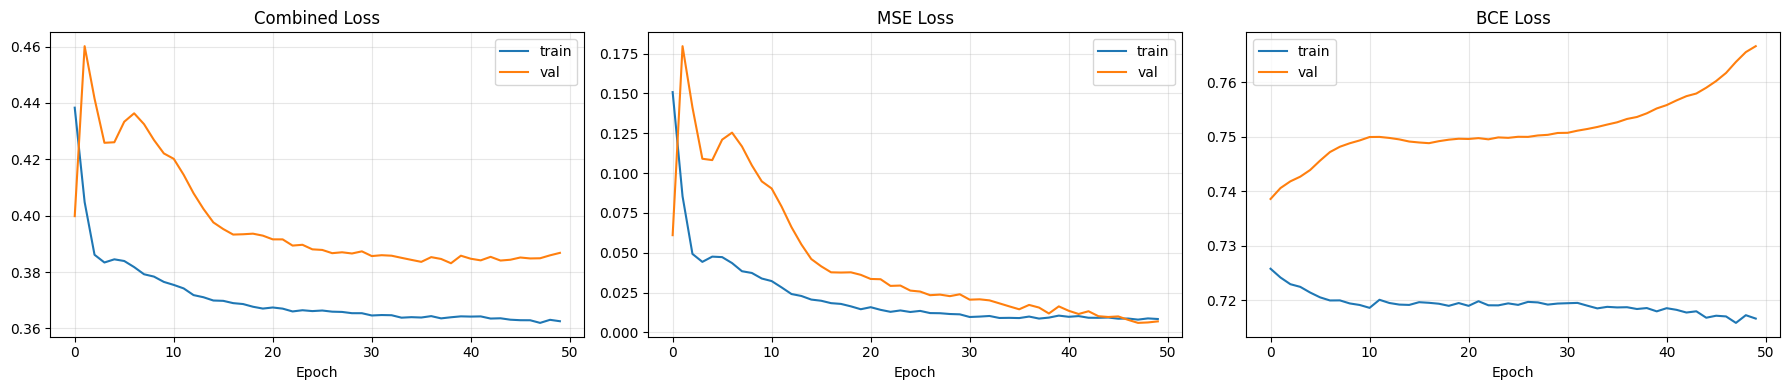

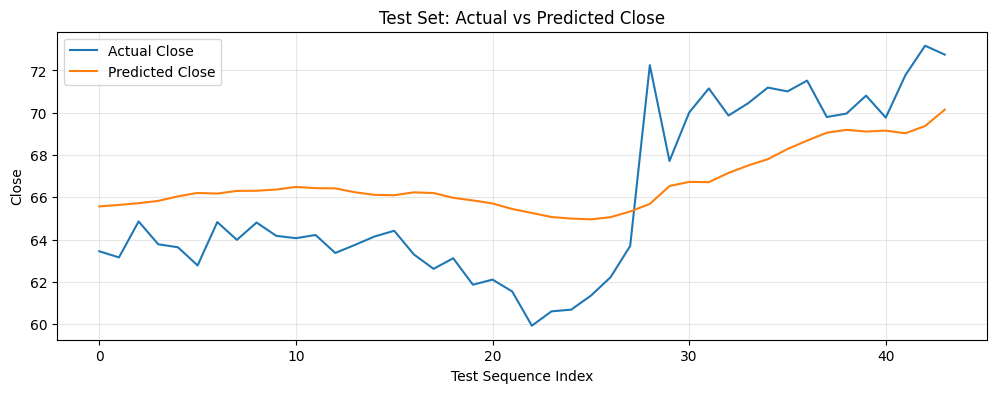

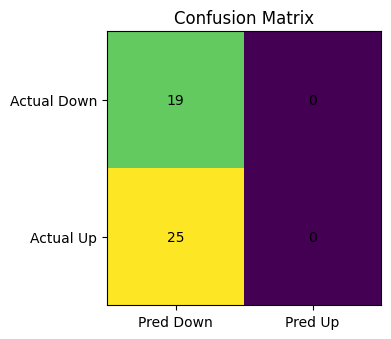

In [9]:
# ── 9. Visualisation ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Combined Loss")
axes[0].set_xlabel("Epoch")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(history["train_mse"], label="train")
axes[1].plot(history["val_mse"], label="val")
axes[1].set_title("MSE Loss")
axes[1].set_xlabel("Epoch")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

axes[2].plot(history["train_bce"], label="train")
axes[2].plot(history["val_bce"], label="val")
axes[2].set_title("BCE Loss")
axes[2].set_xlabel("Epoch")
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(res["true_close"], label="Actual Close")
plt.plot(res["pred_close"], label="Predicted Close")
plt.title("Test Set: Actual vs Predicted Close")
plt.xlabel("Test Sequence Index")
plt.ylabel("Close")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

cm = res["confusion_matrix"]
plt.figure(figsize=(4, 4))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.xticks([0, 1], ["Pred Down", "Pred Up"])
plt.yticks([0, 1], ["Actual Down", "Actual Up"])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.tight_layout()
plt.show()


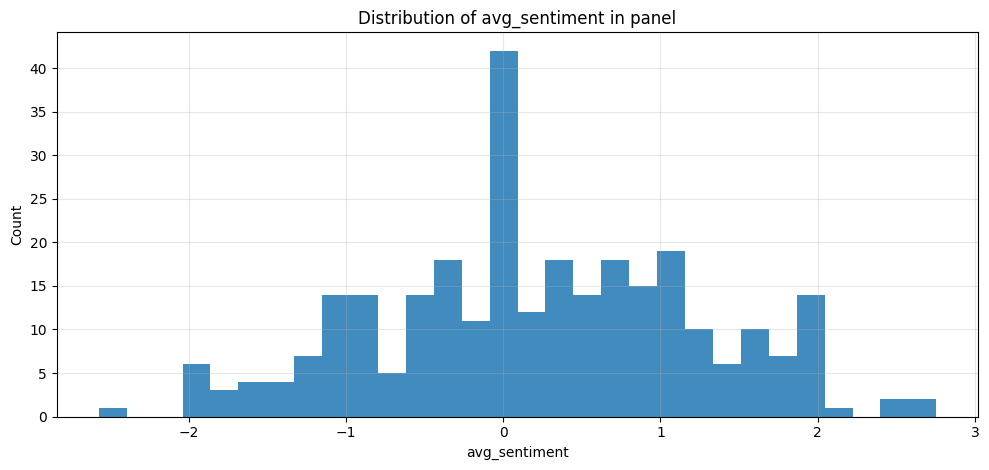

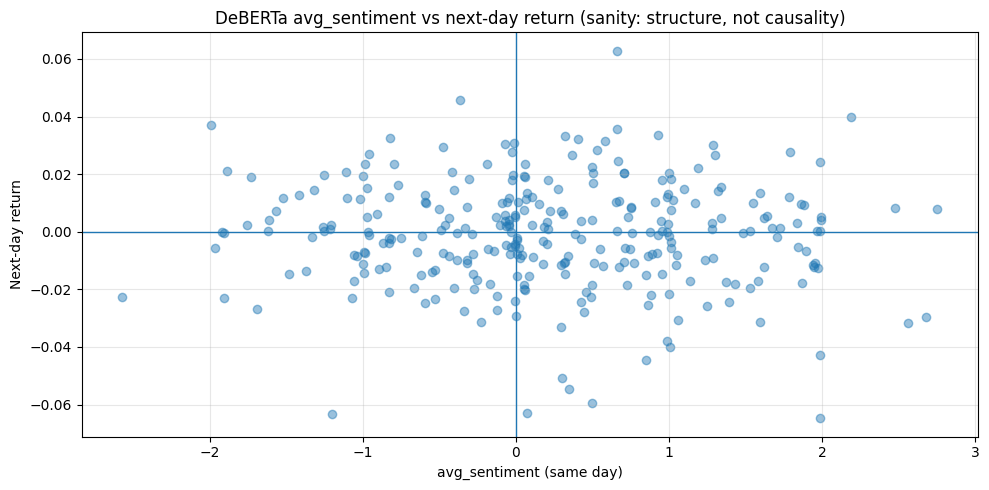

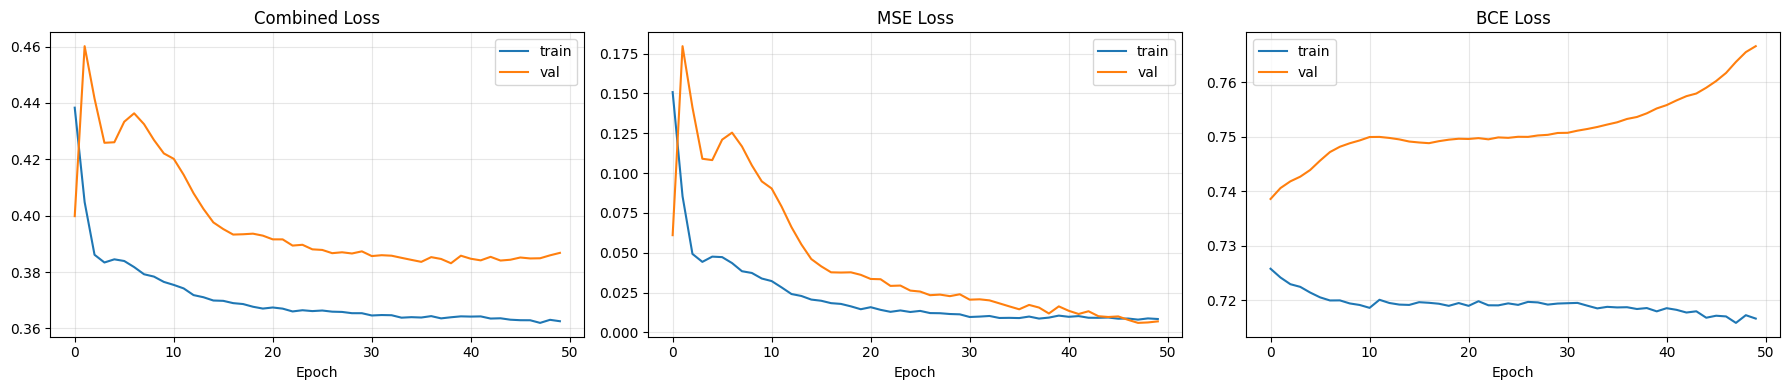

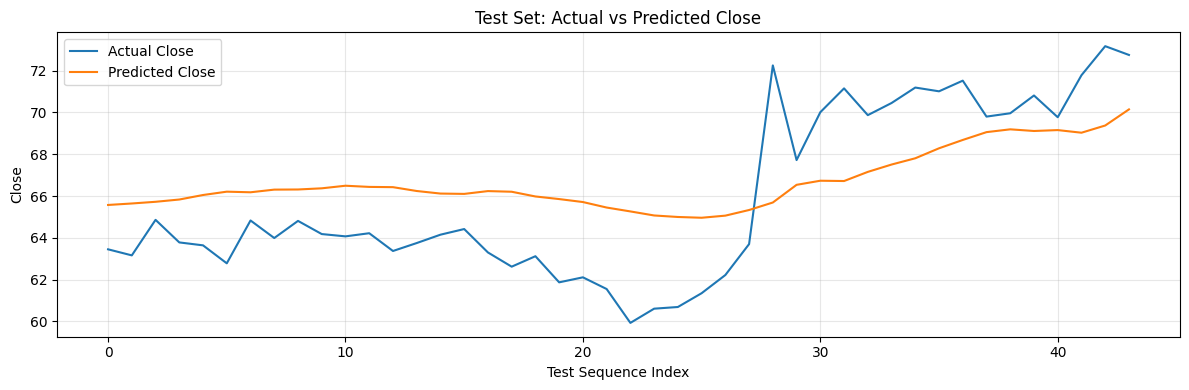

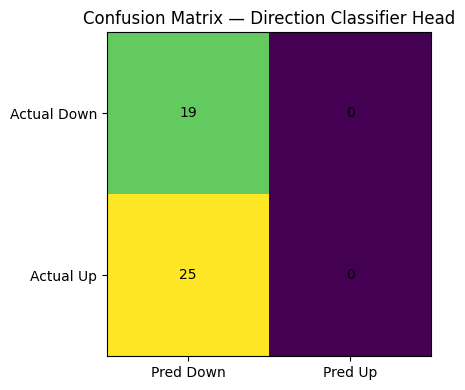

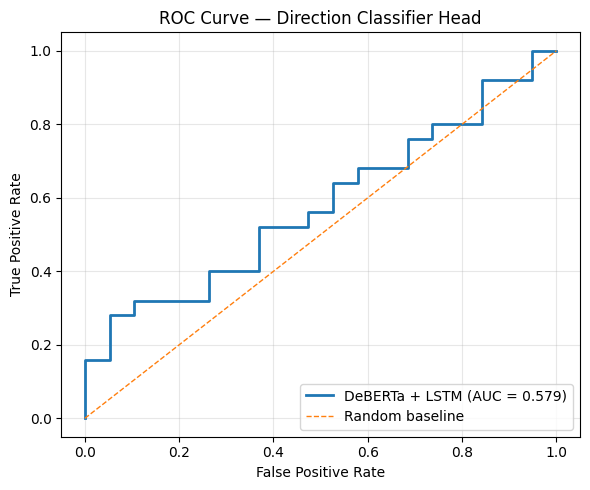

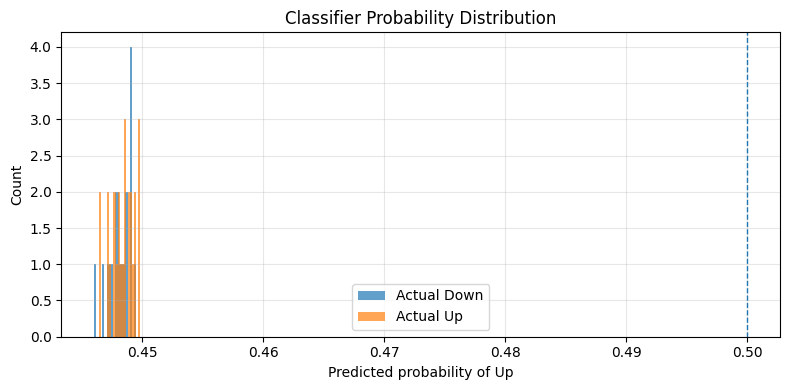

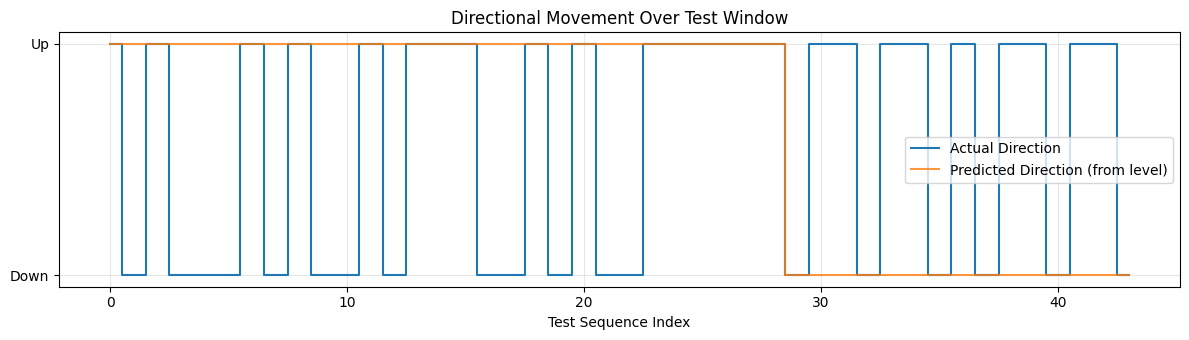

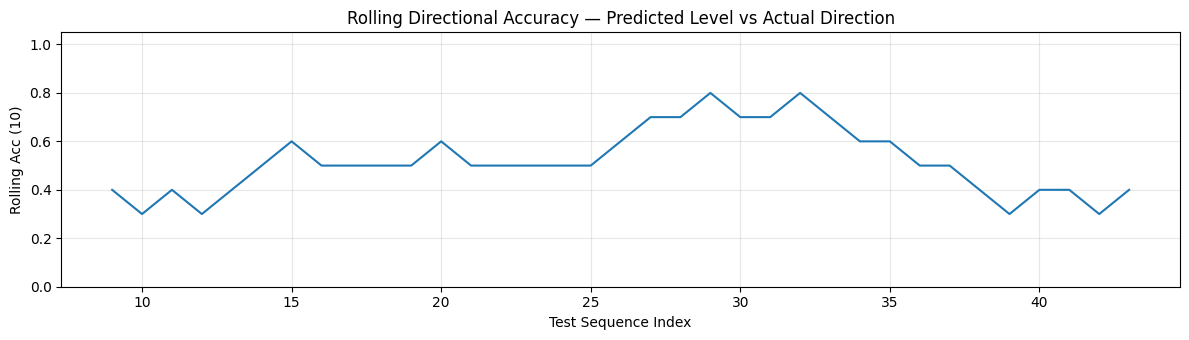


=== Visual summary ===
Regression: RMSE=2.9990 | MAE=2.7417 | MAPE=4.19% | R²=0.4225
Direction from predicted level: acc=50.00% | non-flat=50.00%
Classifier head: acc=43.18% | F1=0.000 | AUC=0.579


In [12]:

# ── 9. Visualisation ─────────────────────────────────────────────────────────
from sklearn.metrics import roc_curve, auc


# 0) Sentiment distribution in the modelling panel
plt.figure(figsize=(10, 4.8))
plt.hist(panel["avg_sentiment"].dropna(), bins=30, alpha=0.85)
plt.xlabel("avg_sentiment")
plt.ylabel("Count")
plt.title("Distribution of avg_sentiment in panel")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 0b) Sentiment vs next-day return sanity plot
plt.figure(figsize=(10, 5))
plt.scatter(
    panel["avg_sentiment"],
    panel["target_return_next"],
    alpha=0.45
)
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.xlabel("avg_sentiment (same day)")
plt.ylabel("Next-day return")
plt.title("DeBERTa avg_sentiment vs next-day return (sanity: structure, not causality)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# 1) Training curves
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Combined Loss")
axes[0].set_xlabel("Epoch")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(history["train_mse"], label="train")
axes[1].plot(history["val_mse"], label="val")
axes[1].set_title("MSE Loss")
axes[1].set_xlabel("Epoch")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

axes[2].plot(history["train_bce"], label="train")
axes[2].plot(history["val_bce"], label="val")
axes[2].set_title("BCE Loss")
axes[2].set_xlabel("Epoch")
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

# 2) Price-level prediction on the test window
plt.figure(figsize=(12, 4))
plt.plot(res["true_close"], label="Actual Close")
plt.plot(res["pred_close"], label="Predicted Close")
plt.title("Test Set: Actual vs Predicted Close")
plt.xlabel("Test Sequence Index")
plt.ylabel("Close")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 3) Confusion matrix for classifier head
cm = res["confusion_matrix"]
plt.figure(figsize=(4.5, 4))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix — Direction Classifier Head")
plt.xticks([0, 1], ["Pred Down", "Pred Up"])
plt.yticks([0, 1], ["Actual Down", "Actual Up"])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.tight_layout()
plt.show()

# 4) ROC curve
y_true = np.asarray(res["true_cls"]).astype(int)
y_prob = np.asarray(res["pred_prob"], dtype=float)

if len(np.unique(y_true)) > 1:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, lw=2, label=f"DeBERTa + LSTM (AUC = {roc_auc:.3f})")
    plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Random baseline")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve — Direction Classifier Head")
    plt.grid(True, alpha=0.3)
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()
else:
    print("ROC curve skipped: test labels contain only one class.")

# 5) Direction probability distribution
plt.figure(figsize=(8, 4))
plt.hist(y_prob[y_true == 0], bins=20, alpha=0.7, label="Actual Down")
plt.hist(y_prob[y_true == 1], bins=20, alpha=0.7, label="Actual Up")
plt.axvline(0.5, linestyle="--", linewidth=1)
plt.xlabel("Predicted probability of Up")
plt.ylabel("Count")
plt.title("Classifier Probability Distribution")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 6) Direction from predicted level vs actual direction over the test window
prev_close = split["target_close_raw"][idx_test - 1]
actual_dir = (res["true_close"] > prev_close).astype(int)
pred_dir = (res["pred_close"] > prev_close).astype(int)

plt.figure(figsize=(12, 3.5))
plt.plot(actual_dir, label="Actual Direction", drawstyle="steps-mid")
plt.plot(pred_dir, label="Predicted Direction (from level)", drawstyle="steps-mid", alpha=0.8)
plt.yticks([0, 1], ["Down", "Up"])
plt.xlabel("Test Sequence Index")
plt.title("Directional Movement Over Test Window")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 7) Rolling directional accuracy (from predicted level)
rolling_window = min(10, len(actual_dir))
if rolling_window >= 2:
    rolling_acc = pd.Series((actual_dir == pred_dir).astype(int)).rolling(rolling_window).mean()

    plt.figure(figsize=(12, 3.5))
    plt.plot(rolling_acc.values)
    plt.ylim(0, 1.05)
    plt.xlabel("Test Sequence Index")
    plt.ylabel(f"Rolling Acc ({rolling_window})")
    plt.title("Rolling Directional Accuracy — Predicted Level vs Actual Direction")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# 8) Small metrics summary for reporting
print("\n=== Visual summary ===")
print(f"Regression: RMSE={res['rmse']:.4f} | MAE={res['mae']:.4f} | MAPE={res['mape']:.2f}% | R²={res['r2']:.4f}")
print(f"Direction from predicted level: acc={res['direction_accuracy']:.2%} | non-flat={res['direction_accuracy_nonzero_actual']:.2%}")
print(f"Classifier head: acc={res['cls_accuracy']:.2%} | F1={res['cls_f1']:.3f} | AUC={res['cls_auc']:.3f}")


,time_steps,alpha,val_loss_min,rmse,mae,mape,r2,dir_acc_lvl,cls_acc,cls_f1,cls_auc,n_test
2,5,0.8,0.165318,4.214159,3.928283,6.067594,-0.140225,0.522727,0.568182,0.724638,0.543158,44
11,30,0.8,0.170399,4.563905,4.165128,6.474619,-0.337340,0.522727,0.431818,0.000000,0.490526,44
8,20,0.8,0.194798,5.751453,4.862455,7.667591,-1.123851,0.659091,0.431818,0.000000,0.507368,44
5,10,0.8,0.208596,6.240925,5.299535,8.358336,-1.500729,0.590909,0.431818,0.000000,0.444211,44
1,5,0.5,0.371814,3.887566,3.672124,5.600949,0.029659,0.500000,0.568182,0.724638,0.541053,44
7,20,0.5,0.387489,5.062555,4.351943,6.844591,-0.645540,0.590909,0.568182,0.724638,0.562105,44
10,30,0.5,0.396074,6.297710,5.329159,8.408938,-1.546444,0.613636,0.568182,0.724638,0.543158,44
4,10,0.5,0.410828,6.017075,5.075873,8.008963,-1.324554,0.681818,0.431818,0.000000,0.450526,44
0,5,0.2,0.591945,5.350188,4.576195,7.197418,-0.837836,0.590909,0.568182,0.724638,0.471579,44
9,30,0.2,0.592679,6.383009,5.391961,8.509908,-1.615892,0.613636,0.568182,0.724638,0.471579,44


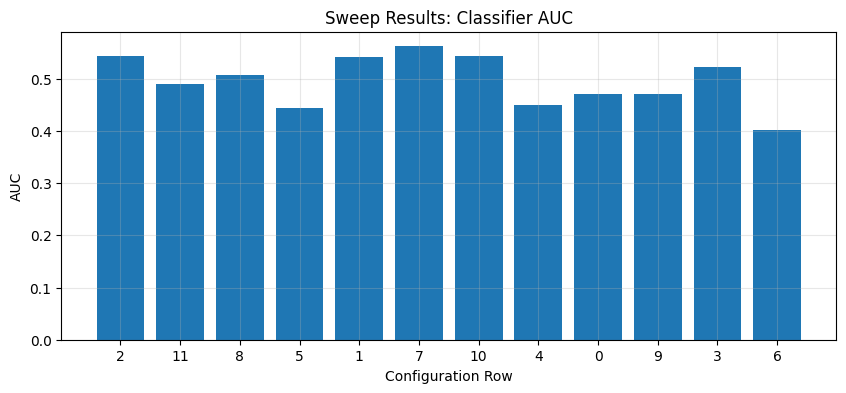

In [10]:
# ── 10. Optional Sweep: TIME_STEPS / LOSS_ALPHA ──────────────────────────────
# Run this only if you want a compact tuning sweep.

def train_eval_multitask(panel_df, feature_cols, time_steps, epochs=30, batch_size=32, alpha=0.5):
    split_local = make_splits(panel_df, feature_cols, time_steps)
    (X_train, y_reg_train, y_cls_train, idx_train) = split_local["train"]
    (X_val, y_reg_val, y_cls_val, idx_val) = split_local["val"]
    (X_test, y_reg_test, y_cls_test, idx_test) = split_local["test"]

    train_loader, val_loader, test_loader = make_loaders(split_local, batch_size=batch_size)

    model_local = MultiTaskLSTM(
        input_size=len(feature_cols),
        hidden_size=HIDDEN_SIZE,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT,
    ).to(DEVICE)

    pos = float(y_cls_train.sum())
    neg = float(len(y_cls_train) - pos)
    pos_weight_value = neg / max(pos, 1.0)
    pos_weight_local = torch.tensor([pos_weight_value], dtype=torch.float32, device=DEVICE)

    mse_local = nn.MSELoss()
    bce_local = nn.BCEWithLogitsLoss(pos_weight=pos_weight_local)
    opt = torch.optim.Adam(model_local.parameters(), lr=LR, weight_decay=1e-4)

    def run_epoch_local(loader, optimizer=None):
        is_train = optimizer is not None
        model_local.train() if is_train else model_local.eval()
        total, n_batches = 0.0, 0
        with torch.set_grad_enabled(is_train):
            for Xb, y_reg_b, y_cls_b in loader:
                Xb = Xb.to(DEVICE)
                y_reg_b = y_reg_b.to(DEVICE)
                y_cls_b = y_cls_b.to(DEVICE)

                pred_reg, pred_logit = model_local(Xb)
                loss_mse = mse_local(pred_reg, y_reg_b)
                loss_bce = bce_local(pred_logit, y_cls_b)
                loss = alpha * loss_mse + (1 - alpha) * loss_bce

                if is_train:
                    optimizer.zero_grad()
                    loss.backward()
                    optimizer.step()

                total += float(loss.item())
                n_batches += 1
        return total / max(n_batches, 1)

    best_val_local = float("inf")
    best_state_local = None
    val_losses = []
    wait_local = 0

    for epoch in range(epochs):
        _ = run_epoch_local(train_loader, optimizer=opt)
        val_loss = run_epoch_local(val_loader, optimizer=None)
        val_losses.append(val_loss)

        if val_loss < best_val_local:
            best_val_local = val_loss
            best_state_local = {k: v.detach().cpu().clone() for k, v in model_local.state_dict().items()}
            wait_local = 0
        else:
            wait_local += 1

        if wait_local >= 10:
            break

    if best_state_local is not None:
        model_local.load_state_dict(best_state_local)

    out = evaluate_model(model_local, test_loader, split_local, idx_test, alpha=alpha)
    out["time_steps"] = time_steps
    out["alpha"] = alpha
    out["val_losses"] = val_losses
    out["n_test_sequences"] = len(X_test)
    return out

time_steps_grid = [5, 10, 20, 30]
alpha_grid = [0.2, 0.5, 0.8]

rows = []
for ts in time_steps_grid:
    for a in alpha_grid:
        out = train_eval_multitask(panel, FEATURE_COLS, ts, epochs=30, batch_size=BATCH_SIZE, alpha=a)
        rows.append({
            "time_steps": ts,
            "alpha": a,
            "val_loss_min": float(np.min(out["val_losses"])) if len(out["val_losses"]) else np.nan,
            "rmse": out["rmse"],
            "mae": out["mae"],
            "mape": out["mape"],
            "r2": out["r2"],
            "dir_acc_lvl": out["direction_accuracy"],
            "cls_acc": out["cls_accuracy"],
            "cls_f1": out["cls_f1"],
            "cls_auc": out["cls_auc"],
            "n_test": out["n_test_sequences"],
        })

sweep_df = pd.DataFrame(rows).sort_values(["val_loss_min", "cls_auc"], ascending=[True, False])
display(sweep_df)

plt.figure(figsize=(10, 4))
plt.bar(sweep_df.index.astype(str), sweep_df["cls_auc"].fillna(0))
plt.title("Sweep Results: Classifier AUC")
plt.xlabel("Configuration Row")
plt.ylabel("AUC")
plt.grid(True, alpha=0.3)
plt.show()
